Dataset Info: 
Shape: (45211, 17)
Columns: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'Class']
   V1            V2       V3         V4  V5    V6   V7   V8       V9  V10  \
0  58    management  married   tertiary  no  2143  yes   no  unknown    5   
1  44    technician   single  secondary  no    29  yes   no  unknown    5   
2  33  entrepreneur  married  secondary  no     2  yes  yes  unknown    5   
3  47   blue-collar  married    unknown  no  1506  yes   no  unknown    5   
4  33       unknown   single    unknown  no     1   no   no  unknown    5   

   V11  V12  V13  V14  V15      V16 Class  
0  may  261    1   -1    0  unknown     1  
1  may  151    1   -1    0  unknown     1  
2  may   76    1   -1    0  unknown     1  
3  may   92    1   -1    0  unknown     1  
4  may  198    1   -1    0  unknown     1  

Target Distribution (y/Class):
Class
1    39922
2     5289
Name: count, dtype: int64
['1', '2']
Categories (2, str):

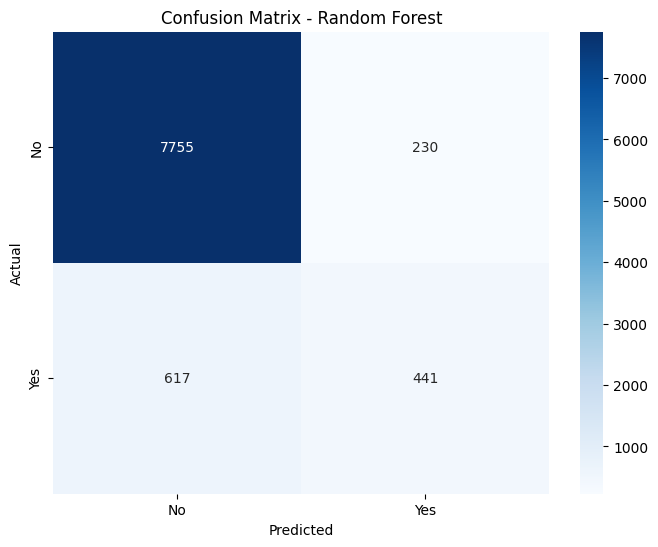

In [20]:
#Random Forest untuk Klasifikasi

#Load & Eksplorasi Data

#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, VotingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score, precision_recall_curve, recall_score)
from sklearn.preprocessing import LabelEncoder, StandardScaler
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

#Load dataset (UCI Bank Marketing Dataset)
# url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip"
url = "https://archive.ics.uci.edu/static/public/222/bank-additional.zip"
# Download manually atau gunakan dataset dari sklearn
from sklearn.datasets import fetch_openml

#Option 1: Gunakan fetch_openml
bank = fetch_openml(data_id=1461, as_frame=True) #bank-marketing dataset
df = bank.frame

print("Dataset Info: ")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(df.head())
print(f"\nTarget Distribution (y/Class):")
print(df['Class'].value_counts())
print(df['Class'].unique())
print(df['Class'].dtype)

#Preprocessing
#Encode categorical variables
categorical_cols = df.select_dtypes(include=['object','category']).columns
for col in categorical_cols:
    if col != 'Class':
        df[col] = LabelEncoder().fit_transform(df[col])

#Encode target
df['Class'] = (df['Class'] == '2').astype(int)

#Split features and target
X = df.drop('Class', axis=1)
y = df['Class']
print(y)

#Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Class distribution in Train: {y_train.value_counts().to_dict()}")

# Tain Random Forest Classifier

#Initialize model
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

#Train model
rf_clf.fit(X_train, y_train)

#Predictions
y_train_pred = rf_clf.predict(X_train)
y_test_pred = rf_clf.predict(X_test)
y_test_proba = rf_clf.predict_proba(X_test)[:, 1]

#Evaluation
print("=== RANDOM FOREST CLASSIFIER ===")
print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Test Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Test F1-Score : {f1_score(y_test, y_test_pred):.4f}")
print(f"Test AUC-ROC  : {roc_auc_score(y_test, y_test_proba):.4f}")

#Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=['No','Yes']))

#Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print(f"cm: {cm}")
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No','Yes'], yticklabels=['No','Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

Decision Tree: AUC = 0.6956 (+/- 0.0110)
Random Forest: AUC = 0.9267 (+/- 0.0021)
AdaBoost: AUC = 0.9008 (+/- 0.0060)
Gradient Boosting: AUC = 0.9227 (+/- 0.0035)
XGBoost: AUC = 0.9310 (+/- 0.0021)


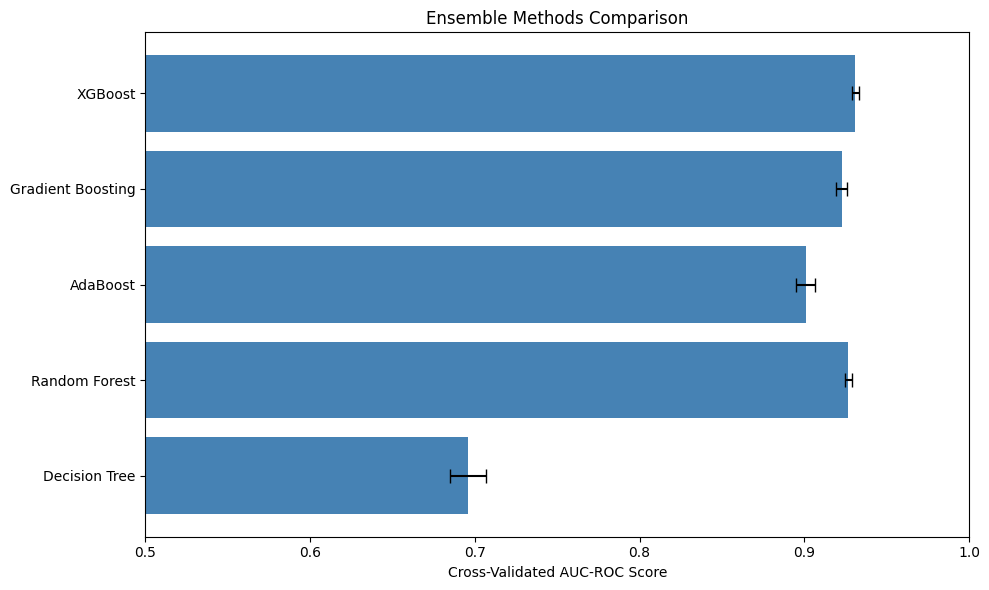

In [ ]:
#Ensemble Methods Comparison

#Compare Different Ensemble Methods
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

#Define models
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'AdaBoost' : AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
}

#Compare models using cross-validation
results = []
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='roc_auc')
    results.append({
        'Model': name,
        'Mean AUC': cv_scores.mean(),
        'Std AUC': cv_scores.std()
    })
    print(f"{name}: AUC = {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

#Visualize Comparison
results_df = pd.DataFrame(results)
plt.figure(figsize=(10,6))
plt.barh(results_df['Model'], results_df['Mean AUC'], xerr=results_df['Std AUC'], color='steelblue', capsize=5)
plt.xlabel('Cross-Validated AUC-ROC Score')
plt.title('Ensemble Methods Comparison')
plt.xlim(0.5, 1.0)
plt.tight_layout()
plt.show()

In [11]:
#Voting Classifier (Combine different algorithms)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
lr_model = LogisticRegression(random_state=42, max_iter=1000)
xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')

#Hard Voting (majority vote)
voting_hard = VotingClassifier(
    estimators=[('rf', rf_model), ('lr', lr_model), ('xgb', xgb_model)],
    voting='hard'
)

#Soft Voting (average probabilities)
voting_soft = VotingClassifier(
    estimators=[('rf', rf_model), ('lr', lr_model), ('xgb', xgb_model)],
    voting='soft'
)

#Train and Evaluate
models_ensemble = {
    'Random Forest': rf_model,
    'Logistic Regression': lr_model,
    'XGBoost': xgb_model,
    'Voting (Hard)': voting_hard,
    'Voting (Soft)': voting_soft
}

print("\n=== Ensemble comparison on test set ===")
for name, model in models_ensemble.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_score)
    else:
        auc = roc_auc_score(y_test, y_pred)
    print(f"{name:20} | AUC: {auc:.4f} | ACC : {accuracy_score(y_test, y_pred):.4f}")



=== Ensemble comparison on test set ===
Random Forest        | AUC: 0.9246 | ACC : 0.9063
Logistic Regression  | AUC: 0.8546 | ACC : 0.8900
XGBoost              | AUC: 0.9267 | ACC : 0.9058
Voting (Hard)        | AUC: 0.6876 | ACC : 0.9073
Voting (Soft)        | AUC: 0.9278 | ACC : 0.9061


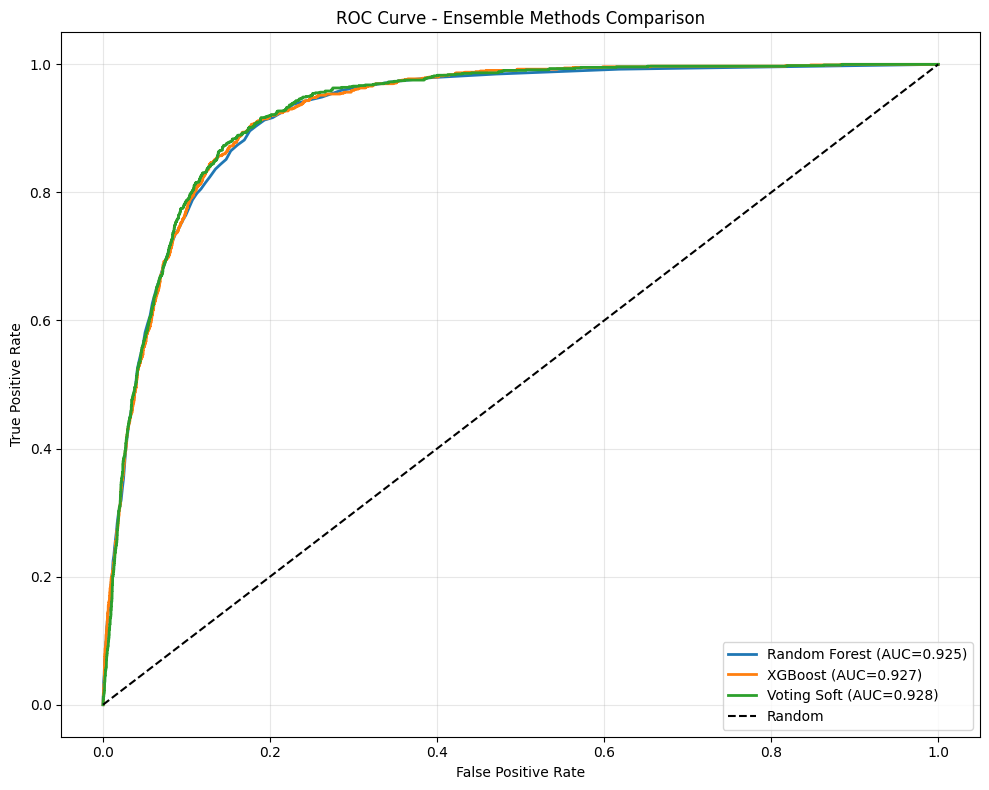

In [17]:
#ROC Curve Comparison
plt.figure(figsize=(10,8))

xgb_model.fit(X_train, y_train)
voting_soft.fit(X_train, y_train)

for name, model in [('Random Forest', rf_clf), ('XGBoost', xgb_model), ('Voting Soft', voting_soft)]:
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', lw=2)

plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Ensemble Methods Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


=== RANDOM FOREST REGRESSOR ===
Train R²: 0.9735
Test R² : 0.8046
Test RMSE: 0.5060
Test MAE : 0.3277

Feature Importance (Regression):
      feature  importance
0      MedInc    0.524980
5    AveOccup    0.138367
6    Latitude    0.089035
7   Longitude    0.088474
1    HouseAge    0.054602
2    AveRooms    0.044216
4  Population    0.030662
3   AveBedrms    0.029663


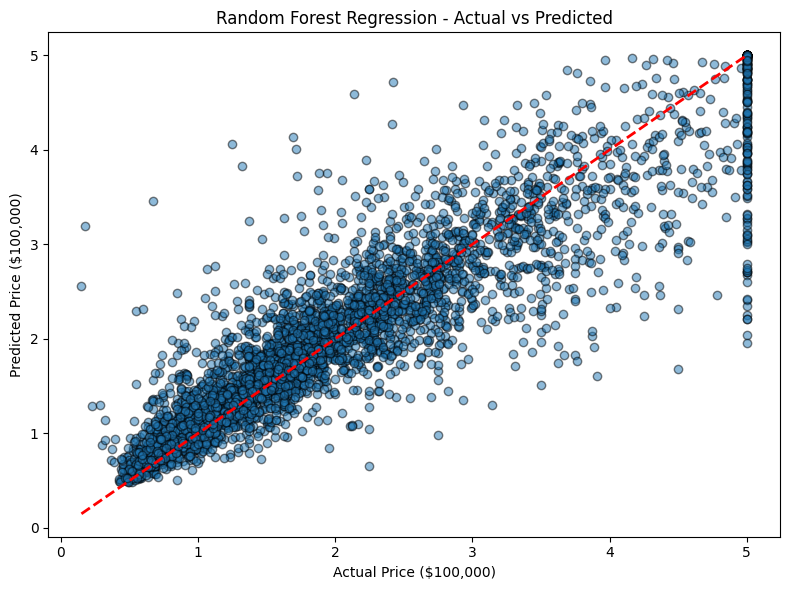

In [19]:
#Random Forest untuk Regresi

#Load Boston-style dataset (California housing dataset)
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
X_h = housing.data
y_h = housing.target

#Train-test split
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_h, y_h, test_size=0.2, random_state=42)

#Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_h, y_train_h)

#Predictions
y_train_pred_h = rf_reg.predict(X_train_h)
y_test_pred_h = rf_reg.predict(X_test_h)

#Evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n=== RANDOM FOREST REGRESSOR ===")
print(f"Train R²: {r2_score(y_train_h, y_train_pred_h):.4f}")
print(f"Test R² : {r2_score(y_test_h, y_test_pred_h):.4f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test_h, y_test_pred_h)):.4f}")
print(f"Test MAE : {mean_absolute_error(y_test_h, y_test_pred_h):.4f}")                                                     

#Feature Importance (for regression)
feature_imp_reg = pd.DataFrame({
    'feature' : housing.feature_names,
    'importance': rf_reg.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nFeature Importance (Regression):")
print(feature_imp_reg)

#Visualization
plt.figure(figsize=(8,6))
plt.scatter(y_test_h, y_test_pred_h, alpha=0.5, edgecolors='k')
plt.plot([y_h.min(), y_h.max()], [y_h.min(), y_h.max()], 'r--', lw=2)
plt.xlabel('Actual Price ($100,000)')
plt.ylabel('Predicted Price ($100,000)')
plt.title('Random Forest Regression - Actual vs Predicted')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

#Cek imbalance
print("Class dsitribution")
print(y_train.value_counts())

#Method 1: Class weight
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
rf_balanced.fit(X_train, y_train)

#Method 2: SMOTE (Synthetic Minority Over-sampling Technique)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

smote = SMOTE(random_state=42)
rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)

pipeline = Pipeline([('smote', smote), ('rf', rf_smote)])
pipeline.fit(X_train, y_train)

#Compare
print("\n=== Handling Imbalanced Data ===")
print(f"Original RF - Recall: {recall_score(y_test, y_test_pred):.4f}")
y_pred_balanced = rf_balanced.predict(X_test)
print(f"Class Weight - Recall: {recall_score(y_test, y_pred_balanced):.4f}")
y_pred_smote = pipeline.predict(X_test)
print(f"SMOTE - Recall: {recall_score(y_test, y_pred_smote):.4f}")

Class dsitribution
Class
0    31937
1     4231
Name: count, dtype: int64

=== Handling Imbalanced Data ===
Original RF - Recall: 0.4168
Class Weight - Recall: 0.6730
SMOTE - Recall: 0.6503


1. Kapan menggunakan Random Forest vs XGBoost?

Random Forest cocok sebagai baseline model karena mudah digunakan, relatif tahan terhadap overfitting, dan memberikan performa yang baik pada banyak dataset. XGBoost lebih cocok ketika diperlukan performa prediksi maksimal pada dataset yang kompleks, karena setiap pohon baru dibangun untuk memperbaiki kesalahan pohon sebelumnya sehingga umumnya menghasilkan akurasi lebih tinggi.

2. Apa trade-off antara akurasi dan interpretability?

Semakin kompleks suatu model, biasanya akurasinya semakin tinggi tetapi interpretasinya semakin sulit. Model sederhana seperti Logistic Regression mudah dijelaskan melalui koefisien fitur, sedangkan model ensemble seperti Random Forest dan XGBoost membutuhkan metode tambahan seperti SHAP untuk memahami pengaruh masing-masing fitur terhadap prediksi.

3. Bagaimana cara mengatasi overfitting pada Random Forest?

Overfitting dapat dikurangi dengan membatasi kedalaman pohon (max_depth), meningkatkan min_samples_split dan min_samples_leaf, melakukan cross-validation, melakukan hyperparameter tuning menggunakan GridSearchCV atau RandomizedSearchCV, serta menambah jumlah dan kualitas data pelatihan.